In [1]:
#BOOTSTRAPPING: statistical method that plot the distribution of a statistics (e.g. mean, median,..)
#by randomly sampling with replacement sets from the sample set,
#of the same size of the original one


In [7]:
lib <- read.table("https://stat4ds.rwth-aachen.de/data/Library.dat", header=TRUE)
lib

length(lib$C)

#n=53 books
#P: number of years since the book publication
#C: number of years since the book checked out (in prestito)

C,P
<int>,<int>
1,3
9,9
4,4
1,18
1,5
30,30
0,17
2,7
0,12


[1] 53

       C                P         
 Min.   : 0.000   Min.   :  3.00  
 1st Qu.: 1.000   1st Qu.:  9.00  
 Median : 4.000   Median : 17.00  
 Mean   : 9.604   Mean   : 21.98  
 3rd Qu.:10.000   3rd Qu.: 19.00  
 Max.   :72.000   Max.   :140.00  

[1] 15.36272

[1] 25.79318

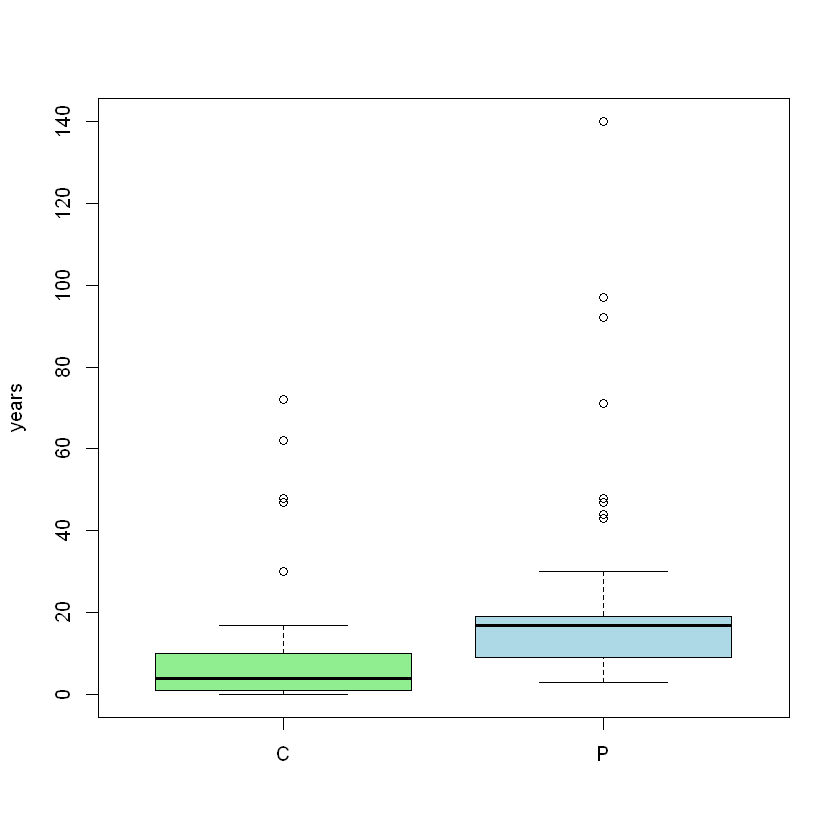

In [15]:
#quick analysis

summary(lib)

sd(lib$C)

sd(lib$P)

boxplot(lib, col=c("lightgreen", "lightblue"), names=c("C", "P"), ylab="years")

#I notice there are pretty remarkable outliers
#-> bootstrap can be used when a sample set is small, but also to diminishing the influence of outliers


20.56604
31.07547
21.45283
22.18868
22.15094
20.05660


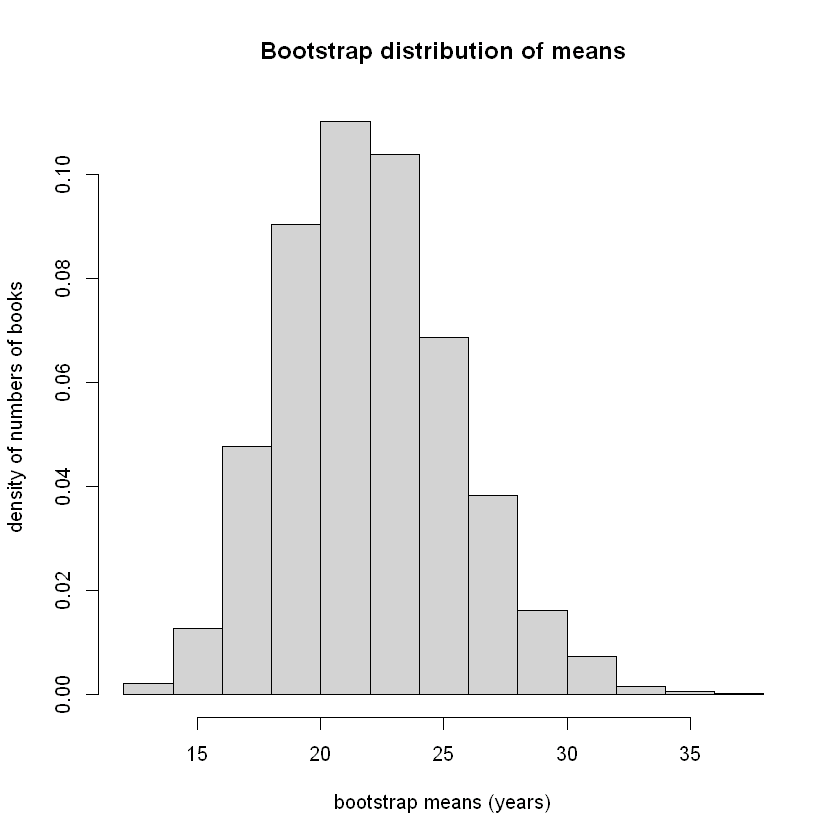

In [65]:
#FOCUS ON THE YEAR OF PUBLICATION: lib$P

library(boot)   #loads package boot for bootstrapping

B <- 10000      #number of resampling of size n=53

results <- boot(lib$P, function(x, b){mean(x[b])}, B)   #boot expects the statistic function
                                                        #x: data (resampled set)
                                                        #b: indices (positions)

#1) sample B random sets
#2) on each one compute the statistics

#boot is an object with many informations

head(results$t)     #$t contains the bootstrapped statistics

hist(results$t,
     probability = TRUE,                    #to print the histogram of probabilities
     xlab = "bootstrap means (years)",
     ylab = "density of numbers of books",
     main = "Bootstrap distribution of means")

In [72]:
#Compute the 95% confidence interval for the mean, employing the bootstrapped distribution

CI <- boot.ci(results)

#outputs 4 CI from 4 different methods
#-> normal: employ the bootstrapped SE
#-> basic: employ the lower and upper quartile of bootstrapped distribution
#-> percent: from 2.5 to 97.5% percentile
#-> BCa: bias-corrected accelerated

CI

CI$percent  #output 0.95 confidence level, lower quartile, upper quartile,
            #CI_low, CI_up

Warning message in boot.ci(results):
"varianze bootstrap necessarie per intervalli studentizzati"


BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 10000 bootstrap replicates

CALL : 
boot.ci(boot.out = results)

Intervals : 
Level      Normal              Basic         
95%   (15.12, 28.89 )   (14.38, 28.19 )  

Level     Percentile            BCa          
95%   (15.77, 29.58 )   (16.58, 31.08 )  
Calculations and Intervals on Original Scale

conf,,,,
0.95,250.03,9750.98,15.77358,29.58443
